# 🎙️ Speech Emotion Recognition — Deliverable 2 (D2)
## Advanced ML Study: Classical Models, Deep Learning, Compression & Dimensionality Reduction
---
> **Dataset**: RAVDESS | **Features**: MFCC (80-dim) from D1  
> **Assumes**: `X.npy`, `y.npy`, `metadata.csv` are saved from D1

## 📦 Section 0 — Install & Import All Dependencies

In [ ]:
# Install any missing packages
!pip install torch torchvision torchaudio --quiet
!pip install scikit-learn matplotlib seaborn pandas numpy --quiet

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, f1_score, mean_squared_error,
    confusion_matrix, ConfusionMatrixDisplay
)

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Fix random seed for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print('✅ All imports successful')
print(f'PyTorch version: {torch.__version__}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

✅ All imports successful
PyTorch version: 2.11.0+cpu
Using device: cpu


## 📂 Section 1 — Load Data from D1

In [ ]:
# Load saved features and labels from D1
X = np.load('X.npy')
y = np.load('y.npy')

print(f'X shape: {X.shape}')   # Expected: (1440, 80)
print(f'y shape: {y.shape}')   # Expected: (1440,)
print(f'Unique classes: {np.unique(y)}')
print(f'Class distribution:\n{pd.Series(y).value_counts().sort_index()}')

X shape: (1440, 80)
y shape: (1440,)
Unique classes: ['Angry' 'Calm' 'Disgust' 'Fearful' 'Happy' 'Neutral' 'Sad' 'Surprised']
Class distribution:
Angry        192
Calm         192
Disgust      192
Fearful      192
Happy        192
Neutral       96
Sad          192
Surprised    192
Name: count, dtype: int64


In [ ]:
# Encode labels to integers if they are strings
le = LabelEncoder()
y_encoded = le.fit_transform(y)
EMOTION_LABELS = le.classes_
NUM_CLASSES = len(EMOTION_LABELS)
print(f'Emotion labels: {EMOTION_LABELS}')
print(f'Number of classes: {NUM_CLASSES}')

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=SEED, stratify=y_encoded
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Train size: {X_train_scaled.shape}, Test size: {X_test_scaled.shape}')

Emotion labels: ['Angry' 'Calm' 'Disgust' 'Fearful' 'Happy' 'Neutral' 'Sad' 'Surprised']
Number of classes: 8
Train size: (1152, 80), Test size: (288, 80)


## 🤖 Section 2 — Classical Machine Learning Models

In [ ]:
# ── Helper: evaluate any sklearn model ──────────────────────────────────────
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    acc  = accuracy_score(y_te, preds)
    f1   = f1_score(y_te, preds, average='macro')
    mse  = mean_squared_error(y_te, preds)
    print(f'[{name:30s}]  Acc={acc:.4f}  F1={f1:.4f}  MSE={mse:.4f}')
    return {'Model': name, 'Accuracy': acc, 'Macro F1': f1, 'MSE': mse,
            'predictions': preds, 'sklearn_model': model}

results = []   # will collect all result dicts

print('=' * 72)
print('CLASSICAL ML RESULTS')
print('=' * 72)

CLASSICAL ML RESULTS


In [ ]:
# ── 2.1  SVM (baseline from D1) ─────────────────────────────────────────────
svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=SEED)
r = evaluate_model('SVM (RBF)', svm,
                   X_train_scaled, y_train, X_test_scaled, y_test)
results.append(r)

[SVM (RBF)                     ]  Acc=0.8229  F1=0.8166  MSE=1.7882


In [ ]:
# ── 2.2  Logistic Regression ────────────────────────────────────────────────
lr = LogisticRegression(max_iter=1000, C=1.0, random_state=SEED)
r = evaluate_model('Logistic Regression', lr,
                   X_train_scaled, y_train, X_test_scaled, y_test)
results.append(r)

[Logistic Regression           ]  Acc=0.5764  F1=0.5661  MSE=5.5590


In [ ]:
# ── 2.3  Random Forest ──────────────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=200, max_depth=None,
                             random_state=SEED, n_jobs=-1)
r = evaluate_model('Random Forest', rf,
                   X_train_scaled, y_train, X_test_scaled, y_test)
results.append(r)

[Random Forest                 ]  Acc=0.6389  F1=0.6321  MSE=4.6771


In [ ]:
# ── 2.4  K-Nearest Neighbors ────────────────────────────────────────────────
knn = KNeighborsClassifier(n_neighbors=7, metric='euclidean')
r = evaluate_model('KNN (k=7)', knn,
                   X_train_scaled, y_train, X_test_scaled, y_test)
results.append(r)

[KNN (k=7)                     ]  Acc=0.5069  F1=0.4739  MSE=6.1875


## 🧠 Section 3 — Full MLP Implementation (PyTorch)

In [ ]:
# ── Hyperparameters ──────────────────────────────────────────────────────────
LEARNING_RATE = 1e-3
BATCH_SIZE    = 32
EPOCHS        = 80
INPUT_DIM     = X_train_scaled.shape[1]   # 80
HIDDEN1       = 128
HIDDEN2       = 64
DROPOUT_RATE  = 0.3

print(f'Hyperparameters: LR={LEARNING_RATE}, BS={BATCH_SIZE},',
      f'Epochs={EPOCHS}, H1={HIDDEN1}, H2={HIDDEN2}')

Hyperparameters: LR=0.001, BS=32, Epochs=80, H1=128, H2=64


In [ ]:
# ── MLP architecture ─────────────────────────────────────────────────────────
class MLP(nn.Module):
    def __init__(self, input_dim, hidden1, hidden2, num_classes, dropout=0.3):
        super(MLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.BatchNorm1d(hidden1),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.BatchNorm1d(hidden2),
            nn.Dropout(dropout),
            nn.Linear(hidden2, num_classes)
        )

    def forward(self, x):
        return self.net(x)

print('MLP architecture:')
demo = MLP(INPUT_DIM, HIDDEN1, HIDDEN2, NUM_CLASSES, DROPOUT_RATE)
print(demo)

MLP architecture:
MLP(
  (net): Sequential(
    (0): Linear(in_features=80, out_features=128, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=8, bias=True)
  )
)


In [ ]:
# ── Build DataLoaders ────────────────────────────────────────────────────────
def make_loaders(X_tr, y_tr, X_te, y_te, batch_size):
    Xtr = torch.FloatTensor(X_tr)
    ytr = torch.LongTensor(y_tr)
    Xte = torch.FloatTensor(X_te)
    yte = torch.LongTensor(y_te)
    train_ds = TensorDataset(Xtr, ytr)
    test_ds  = TensorDataset(Xte, yte)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)
    return train_loader, test_loader

train_loader, test_loader = make_loaders(
    X_train_scaled, y_train, X_test_scaled, y_test, BATCH_SIZE
)
print(f'Train batches: {len(train_loader)}, Test batches: {len(test_loader)}')

Train batches: 36, Test batches: 9


In [ ]:
# ── Training loop ────────────────────────────────────────────────────────────
def train_mlp(model, train_loader, test_loader,
              lr=LEARNING_RATE, epochs=EPOCHS, device=device, verbose=True):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

    train_losses, val_accs = [], []

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0.0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out  = model(Xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * Xb.size(0)
        scheduler.step()

        avg_loss = epoch_loss / len(train_loader.dataset)
        train_losses.append(avg_loss)

        # Validation accuracy
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for Xb, yb in test_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                preds = model(Xb).argmax(dim=1)
                correct += (preds == yb).sum().item()
                total   += yb.size(0)
        val_acc = correct / total
        val_accs.append(val_acc)

        if verbose and epoch % 10 == 0:
            print(f'Epoch [{epoch:3d}/{epochs}]  '
                  f'Loss: {avg_loss:.4f}  Val Acc: {val_acc:.4f}')

    return train_losses, val_accs


def get_mlp_predictions(model, test_loader, device=device):
    model.eval()
    all_preds = []
    with torch.no_grad():
        for Xb, _ in test_loader:
            Xb = Xb.to(device)
            preds = model(Xb).argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
    return np.array(all_preds)

In [ ]:
# ── Train the main MLP ───────────────────────────────────────────────────────
print('Training MLP (PyTorch)...')
mlp_model = MLP(INPUT_DIM, HIDDEN1, HIDDEN2, NUM_CLASSES, DROPOUT_RATE)
train_losses, val_accs = train_mlp(mlp_model, train_loader, test_loader)

mlp_preds = get_mlp_predictions(mlp_model, test_loader)
mlp_acc   = accuracy_score(y_test, mlp_preds)
mlp_f1    = f1_score(y_test, mlp_preds, average='macro')
mlp_mse   = mean_squared_error(y_test, mlp_preds)

print(f'\n[MLP (PyTorch)]  Acc={mlp_acc:.4f}  F1={mlp_f1:.4f}  MSE={mlp_mse:.4f}')
results.append({'Model': 'MLP (PyTorch)', 'Accuracy': mlp_acc,
                'Macro F1': mlp_f1, 'MSE': mlp_mse,
                'predictions': mlp_preds})

Training MLP (PyTorch)...
Epoch [ 10/80]  Loss: 0.8760  Val Acc: 0.6354
Epoch [ 20/80]  Loss: 0.5526  Val Acc: 0.6840
Epoch [ 30/80]  Loss: 0.3857  Val Acc: 0.7292
Epoch [ 40/80]  Loss: 0.3278  Val Acc: 0.7188
Epoch [ 50/80]  Loss: 0.2513  Val Acc: 0.7188
Epoch [ 60/80]  Loss: 0.2444  Val Acc: 0.7431
Epoch [ 70/80]  Loss: 0.2458  Val Acc: 0.7431
Epoch [ 80/80]  Loss: 0.2163  Val Acc: 0.7326

[MLP (PyTorch)]  Acc=0.7326  F1=0.7240  MSE=2.9201


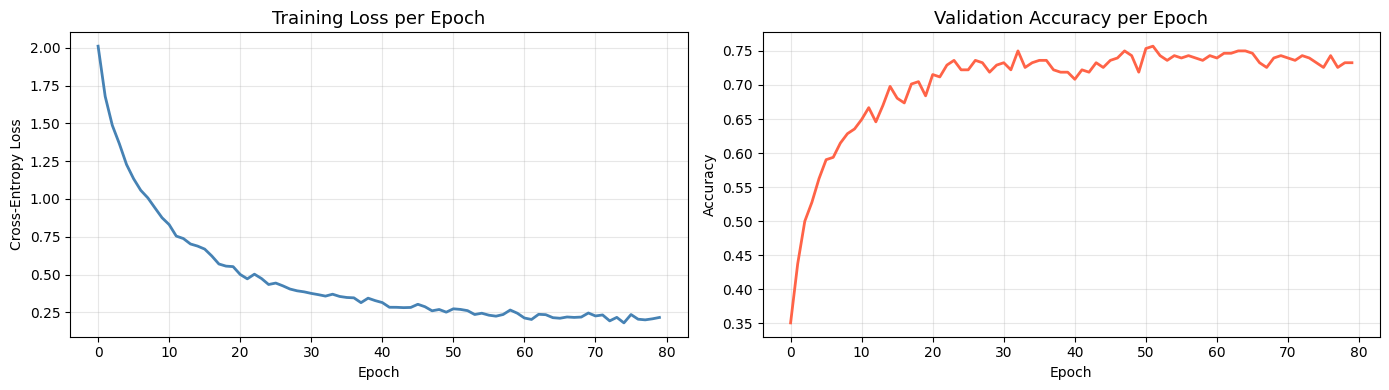

Figure saved: mlp_training_curves.png


In [ ]:
# ── Plot training curves ─────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(train_losses, color='steelblue', linewidth=2)
ax1.set_title('Training Loss per Epoch', fontsize=13)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Cross-Entropy Loss')
ax1.grid(alpha=0.3)

ax2.plot(val_accs, color='tomato', linewidth=2)
ax2.set_title('Validation Accuracy per Epoch', fontsize=13)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('mlp_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: mlp_training_curves.png')

## ✂️ Section 4 — Model Compression Experiments

### 4A — Magnitude-Based Weight Pruning

In [ ]:
import copy

def magnitude_prune(model, prune_ratio=0.3):
    """Zero out the lowest `prune_ratio` fraction of weights by magnitude."""
    pruned_model = copy.deepcopy(model)
    total_pruned = 0
    total_params = 0

    with torch.no_grad():
        for name, param in pruned_model.named_parameters():
            if 'weight' in name:
                flat    = param.data.abs().view(-1)
                thresh  = torch.quantile(flat, prune_ratio)
                mask    = param.data.abs() >= thresh
                total_pruned += (~mask).sum().item()
                total_params += mask.numel()
                param.data   *= mask.float()

    sparsity = total_pruned / total_params * 100
    print(f'Pruning complete — sparsity: {sparsity:.1f}%  '
          f'(pruned {total_pruned}/{total_params} weights)')
    return pruned_model


pruning_results = []
print('Baseline (no pruning):')
base_preds = get_mlp_predictions(mlp_model, test_loader)
pruning_results.append({
    'Prune Ratio': '0% (baseline)',
    'Accuracy': accuracy_score(y_test, base_preds),
    'Macro F1': f1_score(y_test, base_preds, average='macro')
})

for ratio in [0.2, 0.4, 0.6]:
    pm = magnitude_prune(mlp_model, prune_ratio=ratio)
    pp = get_mlp_predictions(pm, test_loader)
    pruning_results.append({
        'Prune Ratio': f'{int(ratio*100)}%',
        'Accuracy': accuracy_score(y_test, pp),
        'Macro F1': f1_score(y_test, pp, average='macro')
    })
    print(f'  Prune {int(ratio*100)}%: Acc={pruning_results[-1]["Accuracy"]:.4f}  '
          f'F1={pruning_results[-1]["Macro F1"]:.4f}')

pruning_df = pd.DataFrame(pruning_results)
print('\nPruning Results:')
print(pruning_df.to_string(index=False))

Baseline (no pruning):
Pruning complete — sparsity: 20.0%  (pruned 3829/19136 weights)
  Prune 20%: Acc=0.6840  F1=0.6755
Pruning complete — sparsity: 40.0%  (pruned 7655/19136 weights)
  Prune 40%: Acc=0.6215  F1=0.6022
Pruning complete — sparsity: 60.0%  (pruned 11481/19136 weights)
  Prune 60%: Acc=0.4410  F1=0.4107

Pruning Results:
  Prune Ratio  Accuracy  Macro F1
0% (baseline)  0.732639  0.723993
          20%  0.684028  0.675477
          40%  0.621528  0.602230
          60%  0.440972  0.410651


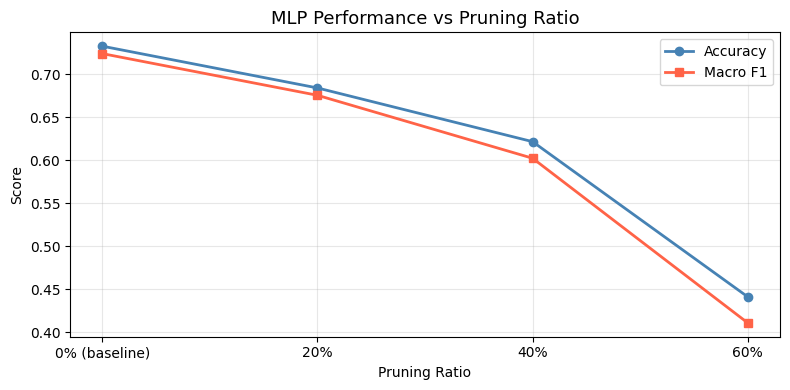

In [ ]:
# Plot pruning effect
fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(pruning_df))
ax.plot(x, pruning_df['Accuracy'], 'o-', label='Accuracy', color='steelblue', linewidth=2)
ax.plot(x, pruning_df['Macro F1'], 's-', label='Macro F1', color='tomato',   linewidth=2)
ax.set_xticks(list(x))
ax.set_xticklabels(pruning_df['Prune Ratio'])
ax.set_title('MLP Performance vs Pruning Ratio', fontsize=13)
ax.set_xlabel('Pruning Ratio'); ax.set_ylabel('Score')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('pruning_results.png', dpi=150, bbox_inches='tight')
plt.show()

### 4B — Quantization (float32 → float16 / int8)

In [ ]:
def quantize_float16(model):
    """Convert model weights to float16."""
    q_model = copy.deepcopy(model).half()   # cast entire model to fp16
    return q_model


def get_mlp_predictions_fp16(model, test_loader, device=device):
    model.eval().to(device)
    all_preds = []
    with torch.no_grad():
        for Xb, _ in test_loader:
            Xb = Xb.to(device).half()   # cast inputs to fp16
            preds = model(Xb).argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
    return np.array(all_preds)


# float16
fp16_model = quantize_float16(mlp_model)
fp16_preds = get_mlp_predictions_fp16(fp16_model, test_loader)
fp16_acc   = accuracy_score(y_test, fp16_preds)
fp16_f1    = f1_score(y_test, fp16_preds, average='macro')

# int8 via dynamic quantization (CPU only)
mlp_cpu   = copy.deepcopy(mlp_model).cpu().eval()
int8_model = torch.quantization.quantize_dynamic(
    mlp_cpu, {nn.Linear}, dtype=torch.qint8
)
int8_preds_list = []
with torch.no_grad():
    for Xb, _ in test_loader:
        out = int8_model(Xb.cpu())
        int8_preds_list.extend(out.argmax(dim=1).numpy())
int8_preds = np.array(int8_preds_list)
int8_acc   = accuracy_score(y_test, int8_preds)
int8_f1    = f1_score(y_test, int8_preds, average='macro')

quant_df = pd.DataFrame([
    {'Precision': 'float32 (baseline)', 'Accuracy': mlp_acc, 'Macro F1': mlp_f1},
    {'Precision': 'float16',            'Accuracy': fp16_acc, 'Macro F1': fp16_f1},
    {'Precision': 'int8 (dynamic)',     'Accuracy': int8_acc, 'Macro F1': int8_f1},
])
print('Quantization Results:')
print(quant_df.to_string(index=False))

Quantization Results:
         Precision  Accuracy  Macro F1
float32 (baseline)  0.732639  0.723993
           float16  0.732639  0.723993
    int8 (dynamic)  0.739583  0.732020


In [ ]:
# Compute model size comparison
def model_size_mb(model):
    total = sum(p.numel() * p.element_size() for p in model.parameters())
    return total / 1e6

print(f'float32 model: {model_size_mb(mlp_model):.4f} MB')
print(f'float16 model: {model_size_mb(fp16_model):.4f} MB')
# int8 dynamic quantization uses platform-specific packing, so approximate
print(f'int8 model (approx): {model_size_mb(mlp_cpu)/4:.4f} MB')

float32 model: 0.0781 MB
float16 model: 0.0391 MB
int8 model (approx): 0.0195 MB


### 4C — Coreset Selection (Train on Data Subset)

In [ ]:
coreset_results = []

for frac in [1.0, 0.7, 0.5, 0.3]:
    if frac < 1.0:
        n_samples = int(len(X_train_scaled) * frac)
        idx = np.random.choice(len(X_train_scaled), n_samples, replace=False)
        Xc, yc = X_train_scaled[idx], y_train[idx]
    else:
        Xc, yc = X_train_scaled, y_train

    c_train_loader, _ = make_loaders(Xc, yc, X_test_scaled, y_test, BATCH_SIZE)

    torch.manual_seed(SEED)
    c_model = MLP(INPUT_DIM, HIDDEN1, HIDDEN2, NUM_CLASSES, DROPOUT_RATE)
    train_mlp(c_model, c_train_loader, test_loader, verbose=False)

    c_preds = get_mlp_predictions(c_model, test_loader)
    c_acc   = accuracy_score(y_test, c_preds)
    c_f1    = f1_score(y_test, c_preds, average='macro')
    coreset_results.append({'Training Set': f'{int(frac*100)}%', 'N': len(Xc),
                            'Accuracy': c_acc, 'Macro F1': c_f1})
    print(f'Coreset {int(frac*100)}% (n={len(Xc)}): Acc={c_acc:.4f}  F1={c_f1:.4f}')

coreset_df = pd.DataFrame(coreset_results)
print('\nCoreset Selection Results:')
print(coreset_df.to_string(index=False))

Coreset 100% (n=1152): Acc=0.7639  F1=0.7529
Coreset 70% (n=806): Acc=0.7014  F1=0.6942
Coreset 50% (n=576): Acc=0.6319  F1=0.6057
Coreset 30% (n=345): Acc=0.5903  F1=0.5730

Coreset Selection Results:
Training Set    N  Accuracy  Macro F1
        100% 1152  0.763889  0.752905
         70%  806  0.701389  0.694205
         50%  576  0.631944  0.605745
         30%  345  0.590278  0.573039


## 📉 Section 5 — Dimensionality Reduction with PCA

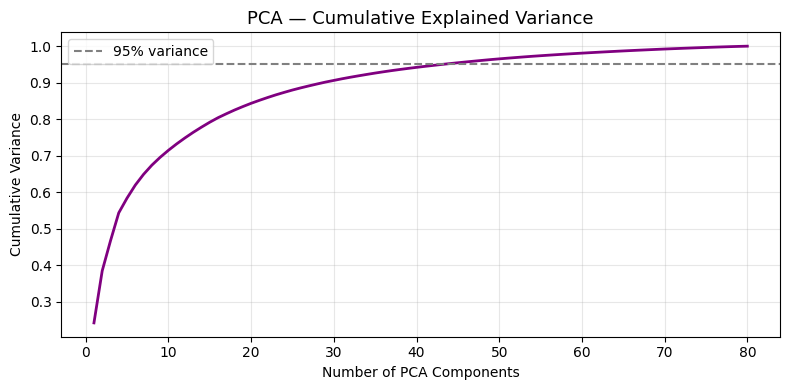

Components to explain 95% variance: 44


In [ ]:
# ── Variance explained curve ─────────────────────────────────────────────────
pca_full = PCA(random_state=SEED)
pca_full.fit(X_train_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumvar)+1), cumvar, color='purple', linewidth=2)
plt.axhline(0.95, linestyle='--', color='gray', label='95% variance')
plt.xlabel('Number of PCA Components'); plt.ylabel('Cumulative Variance')
plt.title('PCA — Cumulative Explained Variance', fontsize=13)
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

n_95 = np.searchsorted(cumvar, 0.95) + 1
print(f'Components to explain 95% variance: {n_95}')

In [ ]:
# ── Apply PCA (80 → 30) ──────────────────────────────────────────────────────
N_COMPONENTS = 30
pca = PCA(n_components=N_COMPONENTS, random_state=SEED)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)
print(f'PCA reduced: {X_train_scaled.shape[1]} → {N_COMPONENTS} dims')
print(f'Explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%')

PCA reduced: 80 → 30 dims
Explained variance: 90.6%


In [ ]:
pca_results = []

# SVM on PCA features
r = evaluate_model('SVM + PCA', SVC(kernel='rbf', C=10, gamma='scale', random_state=SEED),
                   X_train_pca, y_train, X_test_pca, y_test)
pca_results.append(r)

# Logistic Regression on PCA features
r = evaluate_model('LogReg + PCA', LogisticRegression(max_iter=1000, random_state=SEED),
                   X_train_pca, y_train, X_test_pca, y_test)
pca_results.append(r)

# MLP on PCA features
pca_train_loader, pca_test_loader = make_loaders(
    X_train_pca, y_train, X_test_pca, y_test, BATCH_SIZE
)
torch.manual_seed(SEED)
mlp_pca = MLP(N_COMPONENTS, HIDDEN1, HIDDEN2, NUM_CLASSES, DROPOUT_RATE)
train_mlp(mlp_pca, pca_train_loader, pca_test_loader, verbose=False)
pca_mlp_preds = get_mlp_predictions(mlp_pca, pca_test_loader)
pca_mlp_acc   = accuracy_score(y_test, pca_mlp_preds)
pca_mlp_f1    = f1_score(y_test, pca_mlp_preds, average='macro')
print(f'[MLP + PCA]  Acc={pca_mlp_acc:.4f}  F1={pca_mlp_f1:.4f}')
pca_results.append({'Model': 'MLP + PCA', 'Accuracy': pca_mlp_acc,
                    'Macro F1': pca_mlp_f1,
                    'MSE': mean_squared_error(y_test, pca_mlp_preds),
                    'predictions': pca_mlp_preds})

[SVM + PCA                     ]  Acc=0.7188  F1=0.7103  MSE=4.3507
[LogReg + PCA                  ]  Acc=0.5035  F1=0.4831  MSE=6.6181
[MLP + PCA]  Acc=0.6840  F1=0.6571


## 🔁 Section 6 — Multiple MLP Runs (Error Bars / Stability)

In [ ]:
N_RUNS = 5
run_accs, run_f1s = [], []

for run in range(N_RUNS):
    seed = run * 7 + 13
    torch.manual_seed(seed)
    np.random.seed(seed)

    run_model = MLP(INPUT_DIM, HIDDEN1, HIDDEN2, NUM_CLASSES, DROPOUT_RATE)
    run_train_loader, run_test_loader = make_loaders(
        X_train_scaled, y_train, X_test_scaled, y_test, BATCH_SIZE
    )
    train_mlp(run_model, run_train_loader, run_test_loader, verbose=False)

    preds = get_mlp_predictions(run_model, run_test_loader)
    run_accs.append(accuracy_score(y_test, preds))
    run_f1s.append(f1_score(y_test, preds, average='macro'))
    print(f'Run {run+1}/{N_RUNS}: Acc={run_accs[-1]:.4f}  F1={run_f1s[-1]:.4f}')

print(f'\nMLP Accuracy: {np.mean(run_accs):.4f} ± {np.std(run_accs):.4f}')
print(f'MLP Macro F1: {np.mean(run_f1s):.4f} ± {np.std(run_f1s):.4f}')

Run 1/5: Acc=0.7569  F1=0.7470
Run 2/5: Acc=0.7708  F1=0.7672
Run 3/5: Acc=0.7535  F1=0.7386
Run 4/5: Acc=0.7396  F1=0.7317
Run 5/5: Acc=0.7431  F1=0.7352

MLP Accuracy: 0.7528 ± 0.0111
MLP Macro F1: 0.7439 ± 0.0127


## 📊 Section 7 — Confusion Matrices for Best Models

Best classical model: SVM (RBF)


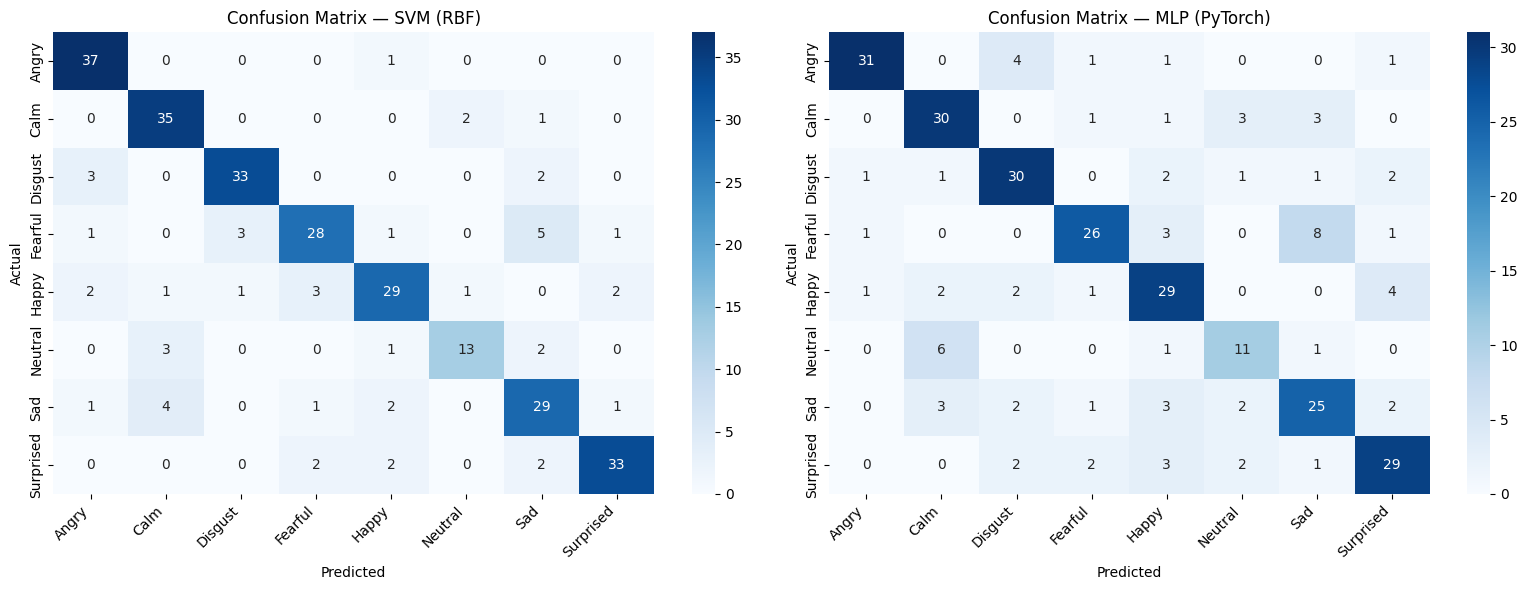

In [ ]:
# Identify best classical model
results_df = pd.DataFrame([{k: v for k, v in r.items()
                             if k not in ('predictions', 'sklearn_model')}
                            for r in results])
best_classical_idx = results_df[results_df['Model'] != 'MLP (PyTorch)']['Accuracy'].idxmax()
best_classical = results[best_classical_idx]
best_model_name = best_classical['Model']
print(f'Best classical model: {best_model_name}')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (name, preds) in zip(axes, [
    (best_model_name, best_classical['predictions']),
    ('MLP (PyTorch)',  mlp_preds)
]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                xticklabels=EMOTION_LABELS, yticklabels=EMOTION_LABELS,
                cmap='Blues')
    ax.set_title(f'Confusion Matrix — {name}', fontsize=12)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 📈 Section 8 — Final Results Table & Bar Plots

In [ ]:
# ── Compile all results ──────────────────────────────────────────────────────
all_results = []

# Classical + MLP
for r in results:
    all_results.append({'Model': r['Model'], 'Accuracy': r['Accuracy'],
                        'Macro F1': r['Macro F1'], 'MSE': r['MSE'],
                        'Note': '—'})

# PCA models
for r in pca_results:
    all_results.append({'Model': r['Model'], 'Accuracy': r['Accuracy'],
                        'Macro F1': r['Macro F1'], 'MSE': r['MSE'],
                        'Note': 'PCA (30-dim)'})

# MLP stability (mean across runs)
all_results.append({
    'Model': 'MLP (5-run mean)',
    'Accuracy': f"{np.mean(run_accs):.4f} ± {np.std(run_accs):.4f}",
    'Macro F1': f"{np.mean(run_f1s):.4f} ± {np.std(run_f1s):.4f}",
    'MSE': '—',
    'Note': 'multi-seed'
})

final_df = pd.DataFrame(all_results)
print('=' * 80)
print('FINAL RESULTS TABLE')
print('=' * 80)
print(final_df.to_string(index=False))
final_df.to_csv('d2_results_table.csv', index=False)
print('\nSaved: d2_results_table.csv')

FINAL RESULTS TABLE
              Model        Accuracy        Macro F1       MSE         Note
          SVM (RBF)        0.822917        0.816569  1.788194            —
Logistic Regression        0.576389        0.566105  5.559028            —
      Random Forest        0.638889        0.632114  4.677083            —
          KNN (k=7)        0.506944        0.473945    6.1875            —
      MLP (PyTorch)        0.732639        0.723993  2.920139            —
          SVM + PCA         0.71875        0.710311  4.350694 PCA (30-dim)
       LogReg + PCA        0.503472        0.483082  6.618056 PCA (30-dim)
          MLP + PCA        0.684028        0.657058  3.885417 PCA (30-dim)
   MLP (5-run mean) 0.7528 ± 0.0111 0.7439 ± 0.0127         —   multi-seed

Saved: d2_results_table.csv


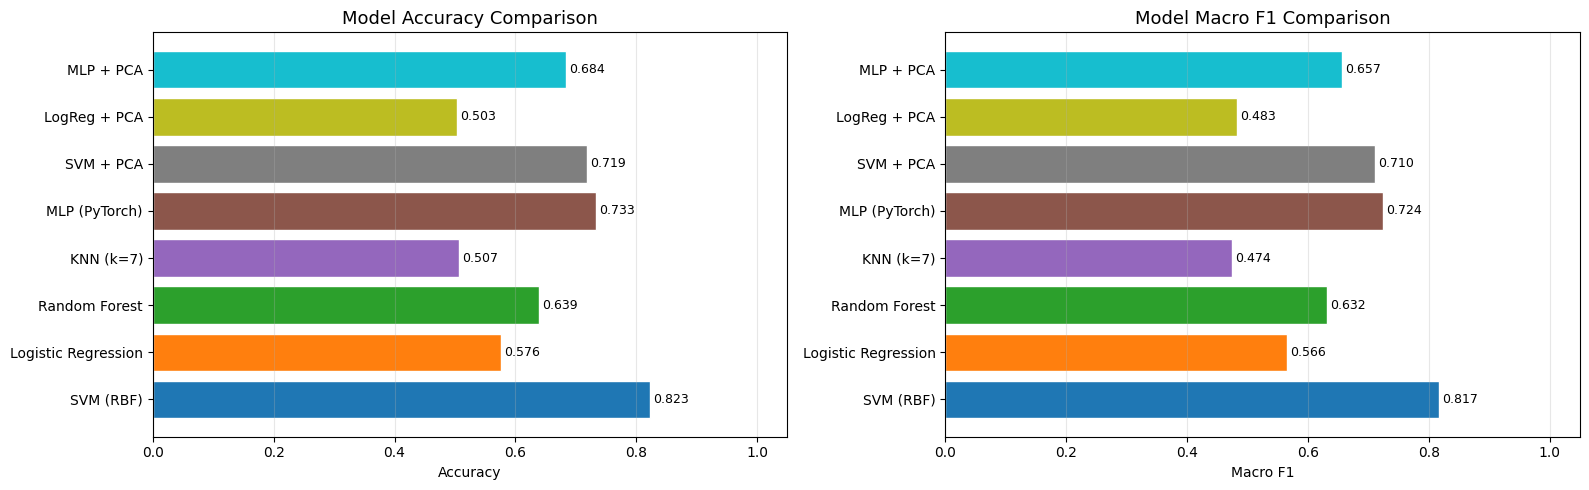

Figure saved: model_comparison.png


In [ ]:
# ── Bar plot: Accuracy & F1 comparison ──────────────────────────────────────
plot_df = pd.DataFrame([r for r in all_results
                        if isinstance(r['Accuracy'], float)])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

colors = plt.cm.tab10(np.linspace(0, 1, len(plot_df)))

bars1 = ax1.barh(plot_df['Model'], plot_df['Accuracy'],
                  color=colors, edgecolor='white')
ax1.set_xlabel('Accuracy'); ax1.set_title('Model Accuracy Comparison', fontsize=13)
ax1.set_xlim(0, 1.05)
for bar, val in zip(bars1, plot_df['Accuracy']):
    ax1.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)
ax1.grid(axis='x', alpha=0.3)

bars2 = ax2.barh(plot_df['Model'], plot_df['Macro F1'],
                  color=colors, edgecolor='white')
ax2.set_xlabel('Macro F1'); ax2.set_title('Model Macro F1 Comparison', fontsize=13)
ax2.set_xlim(0, 1.05)
for bar, val in zip(bars2, plot_df['Macro F1']):
    ax2.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: model_comparison.png')

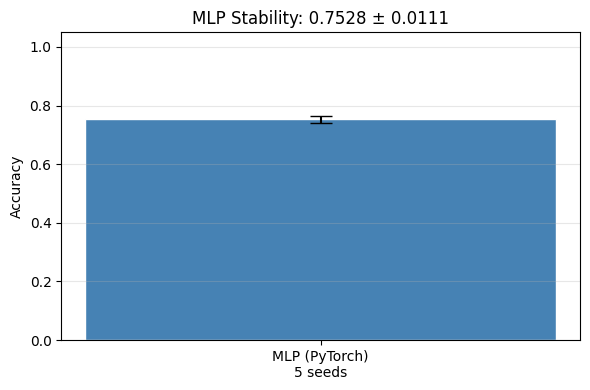

In [ ]:
# ── Error bar plot for multi-run MLP ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['MLP (PyTorch)\n5 seeds'],
       [np.mean(run_accs)],
       yerr=[np.std(run_accs)],
       capsize=8, color='steelblue', edgecolor='white', width=0.4)
ax.set_ylabel('Accuracy')
ax.set_title(f'MLP Stability: {np.mean(run_accs):.4f} ± {np.std(run_accs):.4f}',
             fontsize=12)
ax.set_ylim(0, 1.05); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('mlp_stability.png', dpi=150, bbox_inches='tight')
plt.show()

## 🗂️ Section 9 — Summary & Saved Outputs

In [ ]:
# Save trained MLP checkpoint
torch.save(mlp_model.state_dict(), 'mlp_model.pth')

print('=' * 60)
print('D2 DELIVERABLE — COMPLETED SUCCESSFULLY')
print('=' * 60)
print('Files saved:')
for f in ['d2_results_table.csv', 'mlp_training_curves.png',
          'confusion_matrices.png', 'model_comparison.png',
          'pruning_results.png', 'pca_variance.png',
          'mlp_stability.png', 'mlp_model.pth']:
    print(f'  ✅ {f}')

print('\nExperiments completed:')
print('  ✅ Classical ML: SVM, Logistic Regression, Random Forest, KNN')
print('  ✅ Deep MLP (PyTorch): training curves, val accuracy')
print('  ✅ Pruning (20%, 40%, 60%)')
print('  ✅ Quantization (float16, int8)')
print('  ✅ Coreset selection (30%, 50%, 70%)')
print('  ✅ PCA (80→30 dims): SVM, LogReg, MLP')
print('  ✅ Multi-run stability (5 seeds, mean ± std)')
print('  ✅ Confusion matrices, bar plots, results table')

D2 DELIVERABLE — COMPLETED SUCCESSFULLY
Files saved:
  ✅ d2_results_table.csv
  ✅ mlp_training_curves.png
  ✅ confusion_matrices.png
  ✅ model_comparison.png
  ✅ pruning_results.png
  ✅ pca_variance.png
  ✅ mlp_stability.png
  ✅ mlp_model.pth

Experiments completed:
  ✅ Classical ML: SVM, Logistic Regression, Random Forest, KNN
  ✅ Deep MLP (PyTorch): training curves, val accuracy
  ✅ Pruning (20%, 40%, 60%)
  ✅ Quantization (float16, int8)
  ✅ Coreset selection (30%, 50%, 70%)
  ✅ PCA (80→30 dims): SVM, LogReg, MLP
  ✅ Multi-run stability (5 seeds, mean ± std)
  ✅ Confusion matrices, bar plots, results table
